<a href="https://colab.research.google.com/github/A8stern/PyAD_mobile_2025/blob/main/lab_5_kovalev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №5

**Выполнил: Ковалев Глеб К3341 367291**


## Описание датасета
Для анализа выбрана таблица **“European Football Injuries”** — набор данных о травмах/заболеваниях футболистов из **топ-5 европейских лиг** (Premier League, Bundesliga, La Liga, Serie A, Ligue 1) за сезоны **20/21–24/25**.

**Источник:** Kaggle, "European Football Injuries" : https://www.kaggle.com/datasets/sananmuzaffarov/european-football-injuries-2020-2025?resource=download

## Состав набора данных (поля таблицы)

- **Season** — сезон, к которому относится эпизод травмы (формат вроде `20/21`, `21/22` и т.д.).  
- **Injury** — тип травмы или причина отсутствия (например, *Knee injury*, *Corona virus*, *Ligament injury*).  
- **Days** — длительность отсутствия из-за травмы **в днях**, записанная строкой (например, `43 days`).  
- **Games missed** — количество матчей, пропущенных игроком за период данной травмы/отсутствия.  

- **injury_from_parsed** — дата начала травмы/отсутствия (дата, когда игрок выбыл), в строковом виде (обычно формат `M/D/YYYY`).  
- **injury_until_parsed** — дата окончания травмы/отсутствия (дата возвращения), в строковом виде (обычно формат `M/D/YYYY`).  

- **player_name** — имя и фамилия игрока (полное имя).  
- **player_age** — возраст игрока на момент травмы (в годах).  
- **player_position** — игровая позиция игрока (например, *Goalkeeper*, *Centre-Back* и т.п.).  

- **club** — клуб, за который выступал игрок на момент травмы.  
- **league** — лига, в которой выступает клуб (одна из “большой пятёрки”: *Premier League*, *Bundesliga*, *La Liga*, *Serie A*, *Ligue 1*).

## 0. Загрузка данных

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
data = pd.read_csv('football_injuries.csv')

In [22]:
data.head()

,Season,Injury,Days,Games missed,injury_from_parsed,injury_until_parsed,player_name,player_age,player_position,club,league
0,20/21,Syndesmosis ligament tear,43 days,9,1/28/2021,3/11/2021,Alexander Nübel,24,Goalkeeper,Bayern Munich,Bundesliga
1,20/21,Knee injury,37 days,6,3/7/2021,4/12/2021,Ron-Thorben Hoffmann,22,Goalkeeper,Bayern Munich,Bundesliga
2,20/21,Corona virus,21 days,4,2/17/2021,3/9/2021,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
3,20/21,bruise,8 days,2,11/6/2020,11/13/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
4,20/21,Ligament injury,22 days,2,7/26/2020,8/16/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga


Как видим в данном датасете количество дней это object, я хочу перевести эти данные в числовой тип.

In [23]:
data["Days"] = (
    data["Days"]
    .str.extract(r"(\d+)")
    .astype(float)
)

In [24]:
print(data[["Days"]].head(10))
print(data["Days"].dtype)

   Days
0  43.0
1  37.0
2  21.0
3   8.0
4  22.0
5  48.0
6  52.0
7  61.0
8  19.0
9  74.0
float64


## 1. Описание данных

In [25]:
print("Количество строк и столбцов:")
print("Data shape:", data.shape)

Количество строк и столбцов:
Data shape: (15603, 11)


In [26]:
print("Информация о типах данных:")
print(data.dtypes)

Информация о типах данных:
Season                  object
Injury                  object
Days                   float64
Games missed             int64
injury_from_parsed      object
injury_until_parsed     object
player_name             object
player_age               int64
player_position         object
club                    object
league                  object
dtype: object


## 2. Анализ пропусков

In [27]:
missing_na = data.isna().sum()

missing_na = missing_na[missing_na > 0].sort_values(ascending=False)

print("Явные пропуски (NaN) по столбцам:")
print(missing_na)

Явные пропуски (NaN) по столбцам:
Series([], dtype: int64)


In [28]:
obj_cols = data.select_dtypes(include=["object"]).columns

data[obj_cols] = data[obj_cols].apply(lambda s: s.astype(str).str.strip())

missing_markers = [
    "", " ", "  ", "\t", "\n",
    "?", "??", "-", "--", "—",
    "NA", "N/A", "n/a", "NaN", "nan",
    "NULL", "null", "None", "none",
    "<NA>", "(null)", "missing", "Missing"
]

marker_counts = {}
for col in obj_cols:
    marker_counts[col] = data[col].isin(missing_markers).sum()

marker_counts = pd.Series(marker_counts).sort_values(ascending=False)
print("Скрытые пропуски (по маркерам) в object-колонках:")
print(marker_counts)

data[obj_cols] = data[obj_cols].replace(missing_markers, np.nan)

na_counts2 = data.isna().sum().sort_values(ascending=False)
na_pct2 = (na_counts2 / len(data) * 100).round(2)

summary_na2 = pd.DataFrame({"na_count": na_counts2, "na_%": na_pct2})
print("NaN после замены скрытых маркеров:")
print(summary_na2)

Скрытые пропуски (по маркерам) в object-колонках:
Season                 0
Injury                 0
injury_from_parsed     0
injury_until_parsed    0
player_name            0
player_position        0
club                   0
league                 0
dtype: int64
NaN после замены скрытых маркеров:
                     na_count  na_%
Season                      0   0.0
Injury                      0   0.0
Days                        0   0.0
Games missed                0   0.0
injury_from_parsed          0   0.0
injury_until_parsed         0   0.0
player_name                 0   0.0
player_age                  0   0.0
player_position             0   0.0
club                        0   0.0
league                      0   0.0


In [29]:
num_cols = data.select_dtypes(include=[np.number]).columns

name_candidates = ["player_name"]

name_col = next((c for c in name_candidates if c in data.columns), None)

base_cols = [c for c in [name_col] if c is not None]

nonpos_counts = (data[num_cols] <= 0).sum().sort_values(ascending=False)

nonpos_pct = (nonpos_counts / len(data) * 100).round(2)

summary = pd.DataFrame({
    "count_le_0": nonpos_counts,
    "pct_le_0": nonpos_pct
})

print("Сводка значений <= 0 по числовым столбцам:")
print(summary.loc[summary["count_le_0"] > 0])

suspects = {}
for col in num_cols:
    cond = data[col].isna() | (data[col] <= 0)
    if cond.sum() > 0:
        suspects[col] = data.loc[cond, base_cols + [col]].head(30)

for col, df in suspects.items():
    print(f"\n--- Примеры (NaN или <=0) для столбца '{col}' ---")
    print(df)

Сводка значений <= 0 по числовым столбцам:
Empty DataFrame
Columns: [count_le_0, pct_le_0]
Index: []


Хоть пропусков в моих данных и не оказалось, все равно сделаем тепловую карту, как в задании.

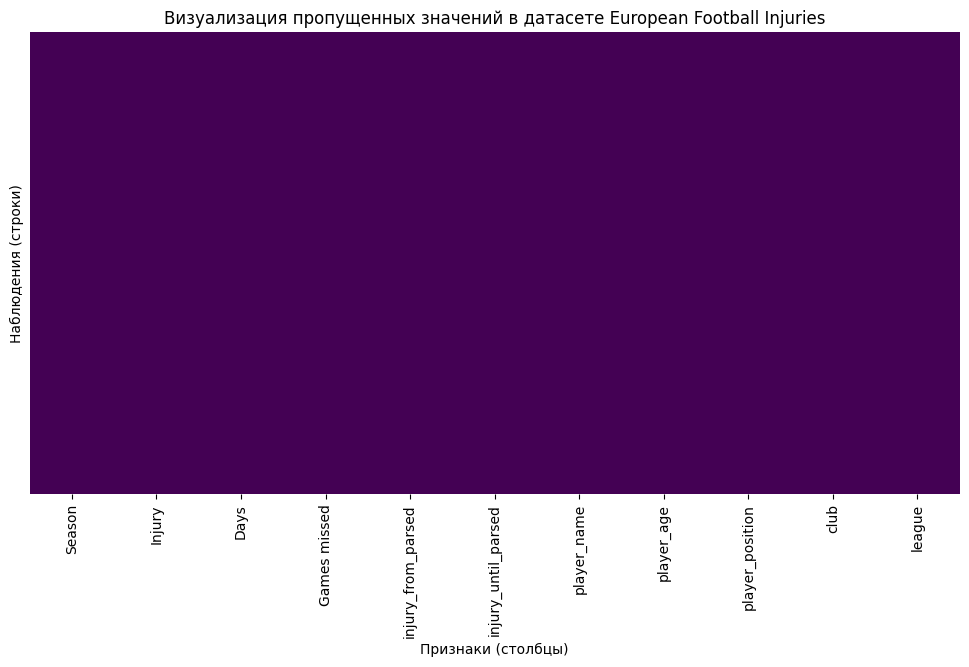

In [30]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    data.isna(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Визуализация пропущенных значений в датасете European Football Injuries")
plt.xlabel("Признаки (столбцы)")
plt.ylabel("Наблюдения (строки)")

plt.show()

## 3. Статистические оценки

In [31]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

print("Числовые признаки:", numeric_cols)
print("Категориальные признаки:", categorical_cols)

print("\n" + "="*50)
print("СТАТИСТИКИ ДЛЯ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*50)

for col in numeric_cols:
    if col not in ['Championships']:
        print(f"\n{col}:")
        print(f"  Среднее: {data[col].mean():.2f}")
        print(f"  Медиана: {data[col].median():.2f}")
        print(f"  Стандартное отклонение: {data[col].std():.2f}")
        print(f"  Минимум: {data[col].min():.2f}")
        print(f"  Максимум: {data[col].max():.2f}")

print("\n" + "="*50)
print("СТАТИСТИКИ ДЛЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("="*50)

for col in categorical_cols:
    if col not in ['player_name', 'injury_from_parsed', 'injury_until_parsed']:
        print(f"\n{col}:")
        value_counts = data[col].value_counts()
        print(f"  Уникальных значений: {data[col].nunique()}")
        print(f"  Мода: {data[col].mode().iloc[0] if not data[col].mode().empty else 'Нет данных'}")
        print(f"  Распределение (топ-5):")
        for value, count in value_counts.head().items():
            print(f"    {value}: {count} ({count/len(data)*100:.1f}%)")


Числовые признаки: ['Days', 'Games missed', 'player_age']
Категориальные признаки: ['Season', 'Injury', 'injury_from_parsed', 'injury_until_parsed', 'player_name', 'player_position', 'club', 'league']

СТАТИСТИКИ ДЛЯ ЧИСЛОВЫХ ПРИЗНАКОВ

Days:
  Среднее: 36.10
  Медиана: 18.00
  Стандартное отклонение: 54.42
  Минимум: 1.00
  Максимум: 1013.00

Games missed:
  Среднее: 5.51
  Медиана: 3.00
  Стандартное отклонение: 7.64
  Минимум: 1.00
  Максимум: 145.00

player_age:
  Среднее: 26.55
  Медиана: 26.00
  Стандартное отклонение: 4.40
  Минимум: 16.00
  Максимум: 43.00

СТАТИСТИКИ ДЛЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

Season:
  Уникальных значений: 5
  Мода: 21/22
  Распределение (топ-5):
    21/22: 3406 (21.8%)
    24/25: 3279 (21.0%)
    20/21: 3181 (20.4%)
    23/24: 2873 (18.4%)
    22/23: 2864 (18.4%)

Injury:
  Уникальных значений: 276
  Мода: Hamstring injury
  Распределение (топ-5):
    Hamstring injury: 1256 (8.0%)
    Corona virus: 986 (6.3%)
    Muscle injury: 960 (6.2%)
    muscular pro

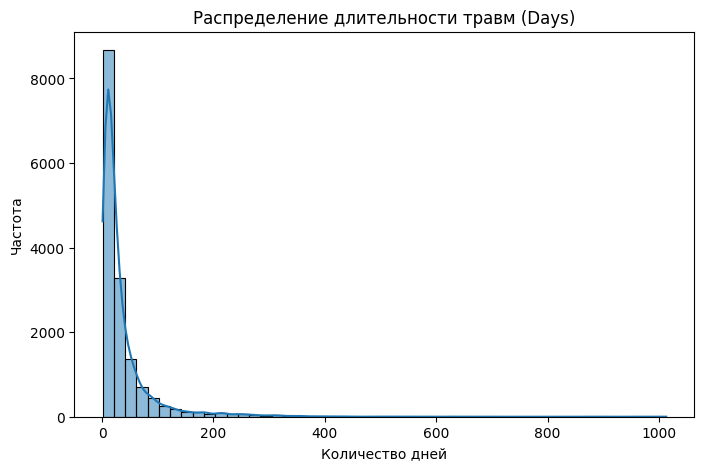

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Days"], bins=50, kde=True)
plt.title("Распределение длительности травм (Days)")
plt.xlabel("Количество дней")
plt.ylabel("Частота")
plt.show()

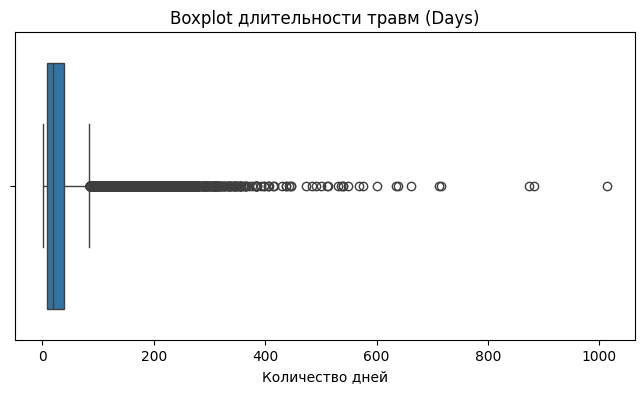

In [33]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data["Days"])
plt.title("Boxplot длительности травм (Days)")
plt.xlabel("Количество дней")
plt.show()

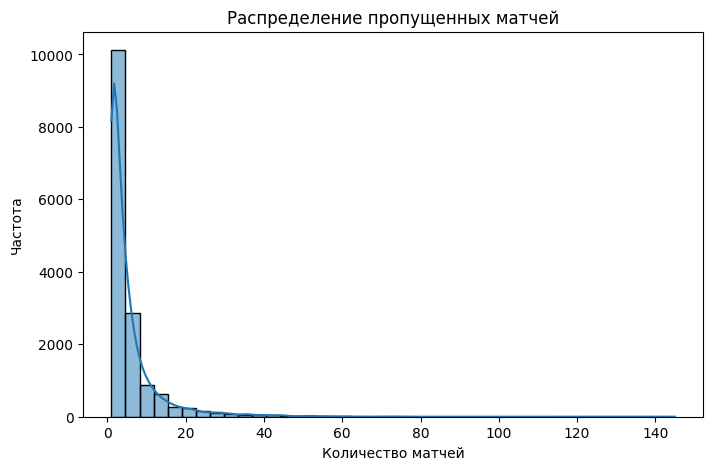

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Games missed"], bins=40, kde=True)
plt.title("Распределение пропущенных матчей")
plt.xlabel("Количество матчей")
plt.ylabel("Частота")
plt.show()

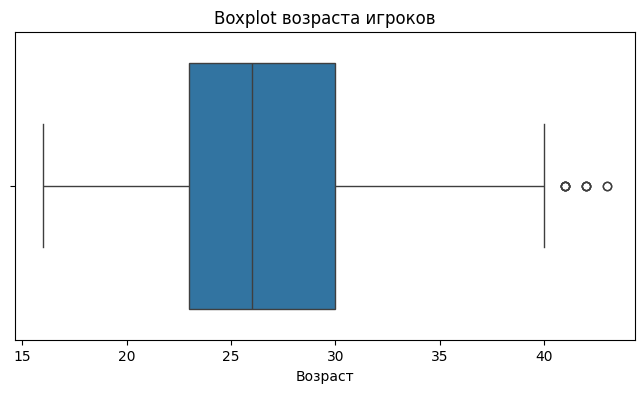

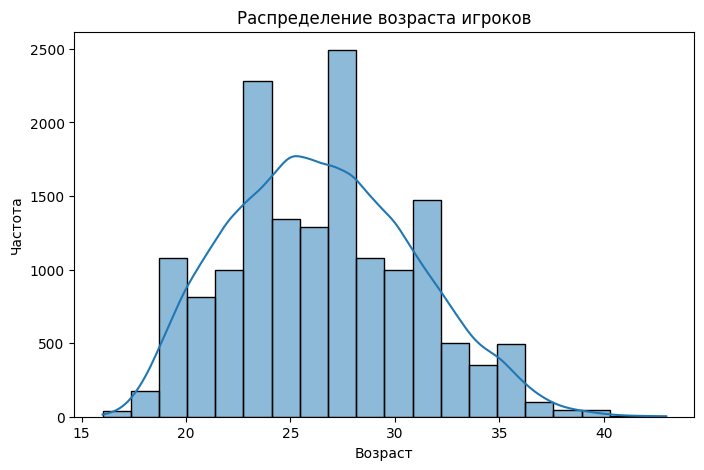

In [35]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data["player_age"])
plt.title("Boxplot возраста игроков")
plt.xlabel("Возраст")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data["player_age"], bins=20, kde=True)
plt.title("Распределение возраста игроков")
plt.xlabel("Возраст")
plt.ylabel("Частота")
plt.show()

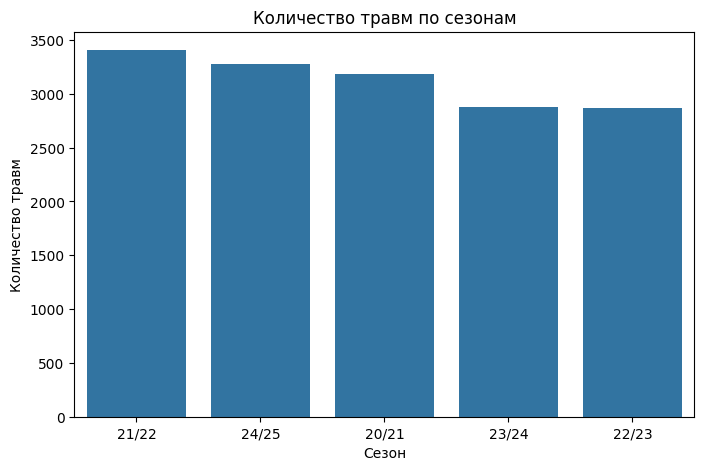

In [36]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=data,
    x="Season",
    order=data["Season"].value_counts().index
)
plt.title("Количество травм по сезонам")
plt.xlabel("Сезон")
plt.ylabel("Количество травм")
plt.show()

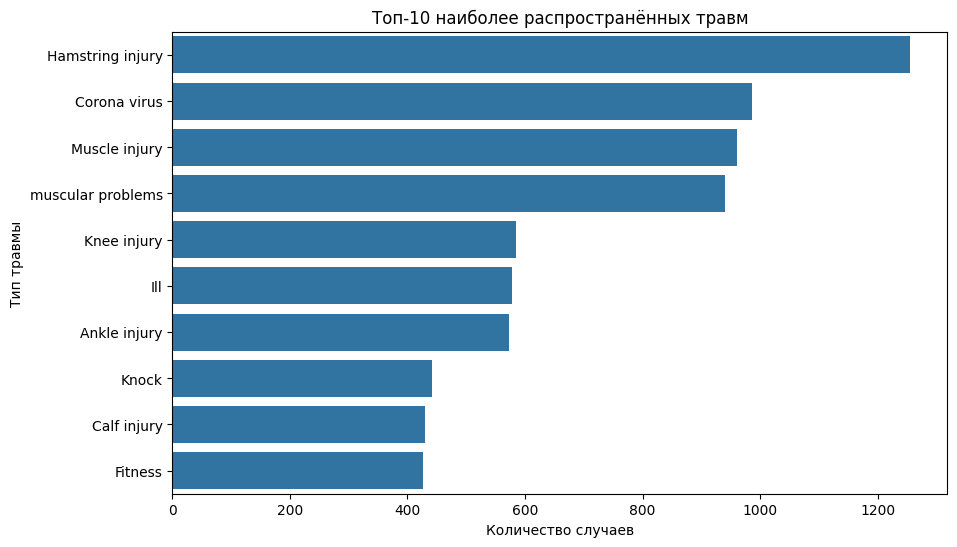

In [37]:
top_injuries = data["Injury"].value_counts().head(10).index

plt.figure(figsize=(10, 6))
sns.countplot(
    data=data,
    y="Injury",
    order=top_injuries
)
plt.title("Топ-10 наиболее распространённых травм")
plt.xlabel("Количество случаев")
plt.ylabel("Тип травмы")
plt.show()

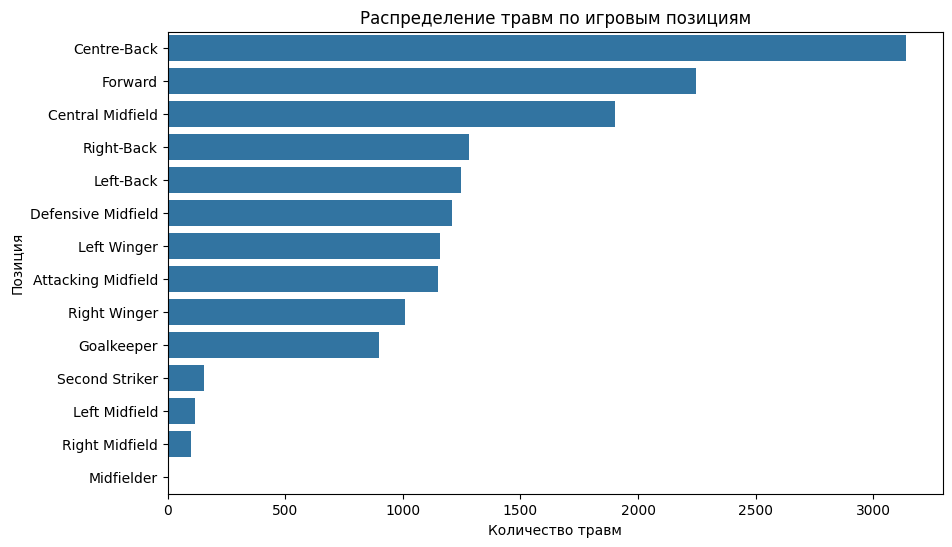

In [38]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=data,
    y="player_position",
    order=data["player_position"].value_counts().index
)
plt.title("Распределение травм по игровым позициям")
plt.xlabel("Количество травм")
plt.ylabel("Позиция")
plt.show()

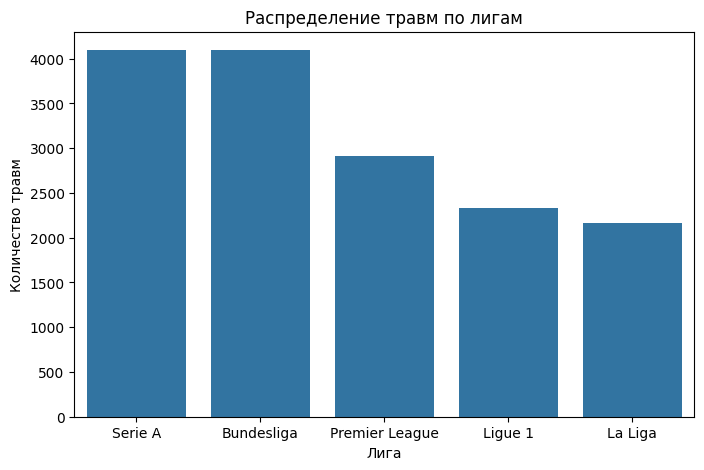

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=data,
    x="league",
    order=data["league"].value_counts().index
)
plt.title("Распределение травм по лигам")
plt.xlabel("Лига")
plt.ylabel("Количество травм")
plt.show()

## 4. Выявление аномалий (выбросов)

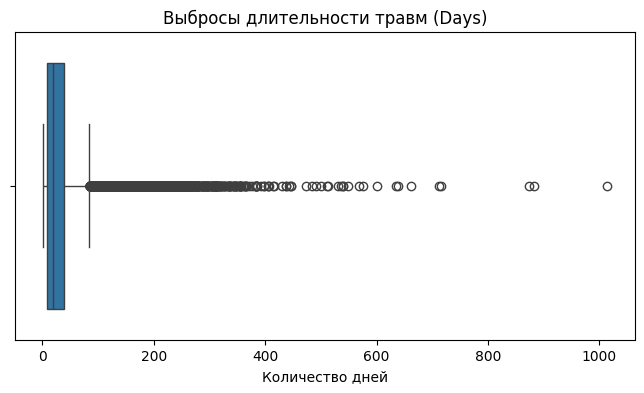

In [40]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data["Days"])
plt.title("Выбросы длительности травм (Days)")
plt.xlabel("Количество дней")
plt.show()

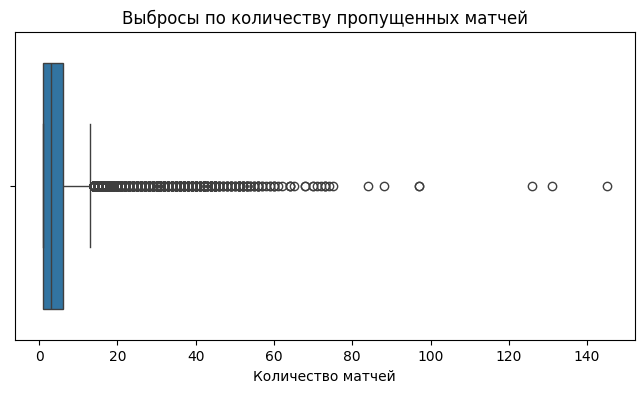

In [41]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data["Games missed"])
plt.title("Выбросы по количеству пропущенных матчей")
plt.xlabel("Количество матчей")
plt.show()

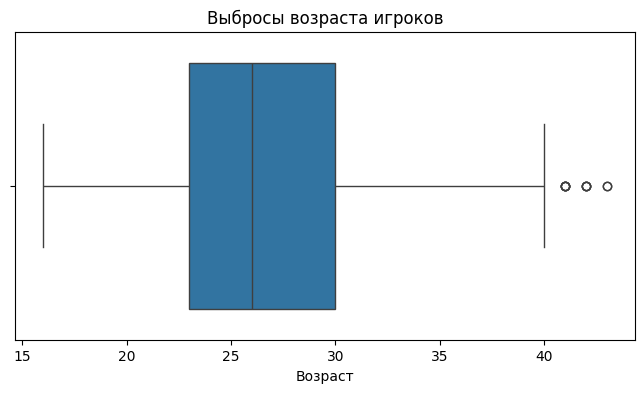

In [42]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data["player_age"])
plt.title("Выбросы возраста игроков")
plt.xlabel("Возраст")
plt.show()

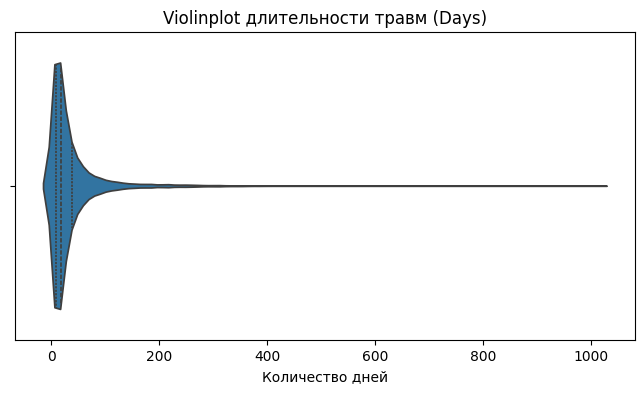

In [43]:
plt.figure(figsize=(8, 4))
sns.violinplot(x=data["Days"], inner="quartile")
plt.title("Violinplot длительности травм (Days)")
plt.xlabel("Количество дней")
plt.show()

In [44]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers_days, low_d, high_d = detect_outliers_iqr(data["Days"])

print(f"Границы нормальных значений Days: [{low_d:.2f}, {high_d:.2f}]")
print(f"Количество выбросов: {len(outliers_days)}")

outliers_games, low_g, high_g = detect_outliers_iqr(data["Games missed"])

print(f"Границы нормальных значений Games missed: [{low_g:.2f}, {high_g:.2f}]")
print(f"Количество выбросов: {len(outliers_games)}")

outliers_age, low_a, high_a = detect_outliers_iqr(data["player_age"])

print(f"Границы нормальных значений player_age: [{low_a:.2f}, {high_a:.2f}]")
print(f"Количество выбросов: {len(outliers_age)}")

Границы нормальных значений Days: [-36.00, 84.00]
Количество выбросов: 1497
Границы нормальных значений Games missed: [-6.50, 13.50]
Количество выбросов: 1367
Границы нормальных значений player_age: [12.50, 40.50]
Количество выбросов: 11


Для признаков Days и Games missed выбросы обусловлены тяжелыми травмами, длительными реабилитациями и хроническими заболеваниями. Для признака player_age выбросы являются естественными и не требуют удаления.

## 5. Визуализация с помощью seaborn

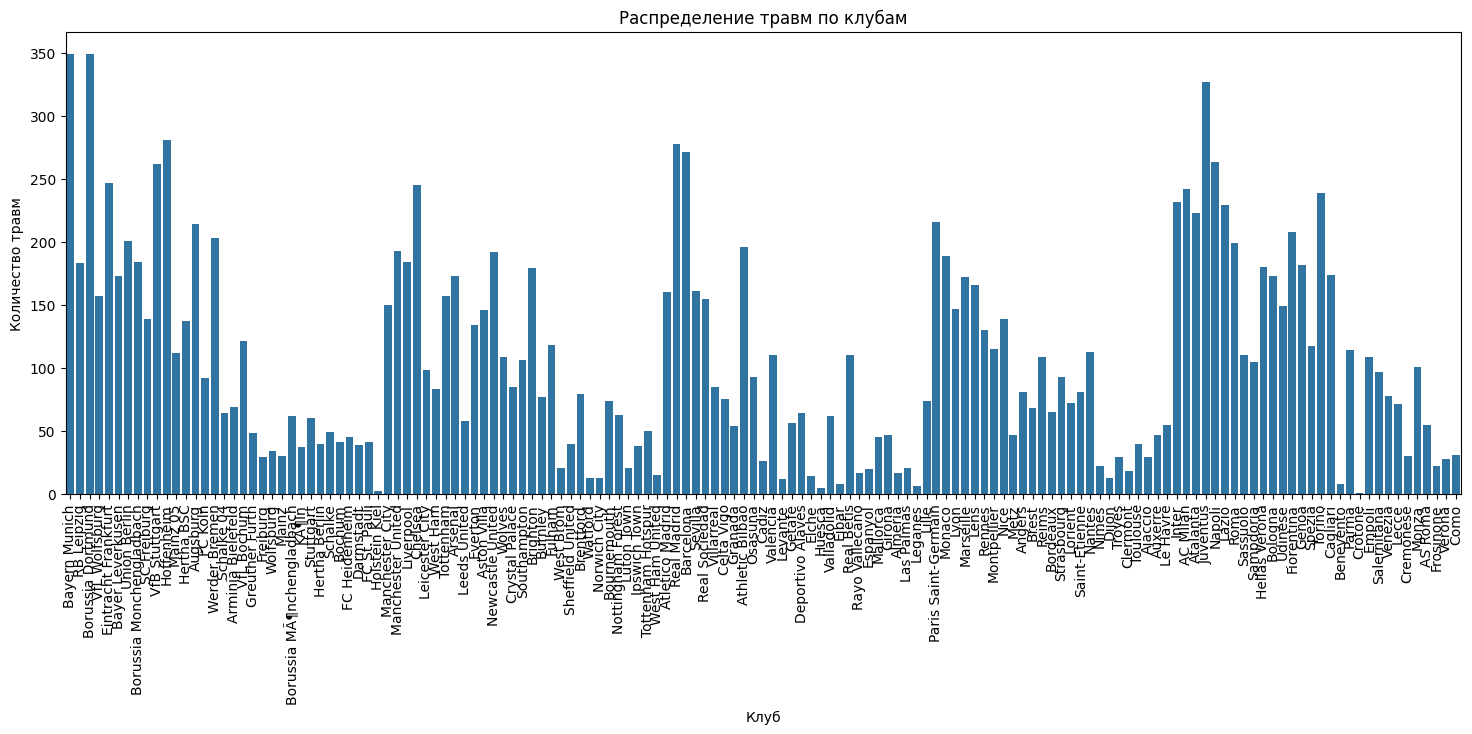

In [45]:
plt.figure(figsize=(18, 6))
sns.countplot(data=data, x="club")

plt.title("Распределение травм по клубам")
plt.xlabel("Клуб")
plt.ylabel("Количество травм")
plt.xticks(rotation=90)
plt.show()

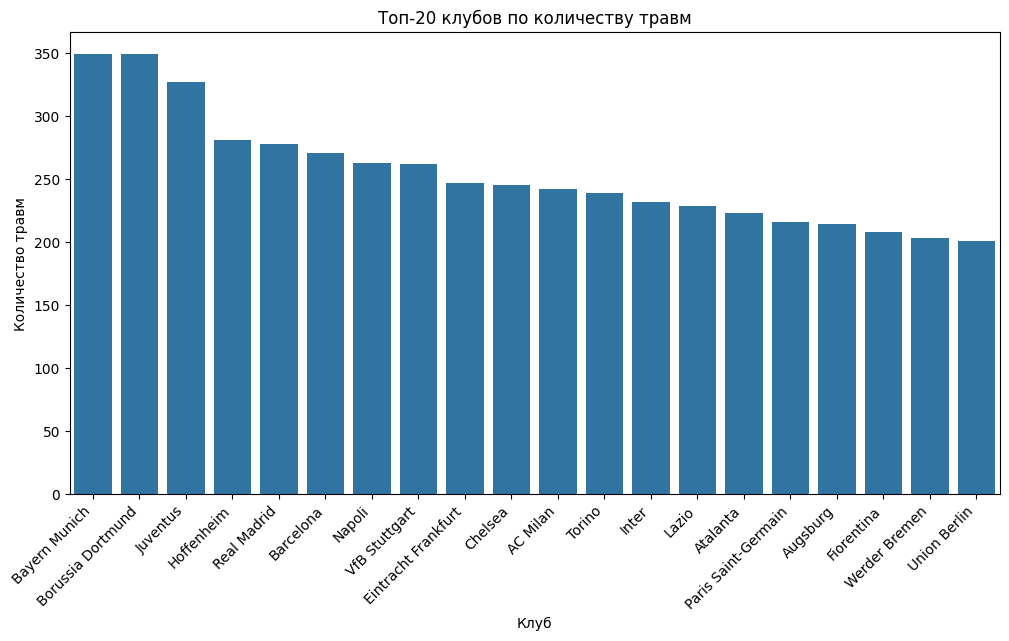

In [46]:
top_clubs = data["club"].value_counts().head(20).index

plt.figure(figsize=(12, 6))
sns.countplot(
    data=data,
    x="club",
    order=top_clubs
)

plt.title("Топ-20 клубов по количеству травм")
plt.xlabel("Клуб")
plt.ylabel("Количество травм")
plt.xticks(rotation=45, ha="right")
plt.show()

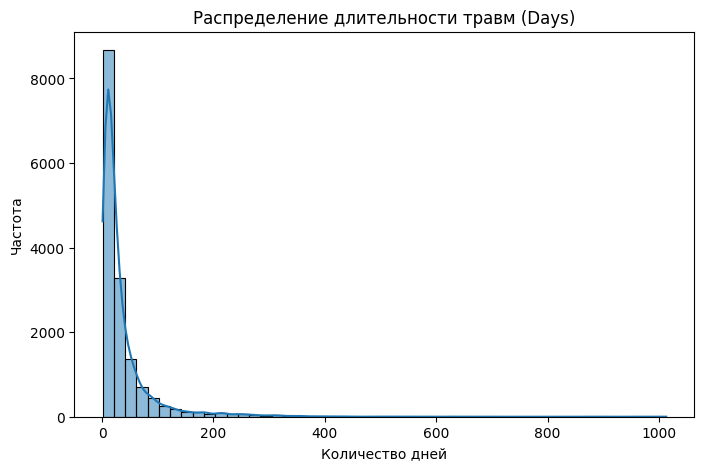

In [47]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=data,
    x="Days",
    bins=50,
    kde=True
)

plt.title("Распределение длительности травм (Days)")
plt.xlabel("Количество дней")
plt.ylabel("Частота")
plt.show()

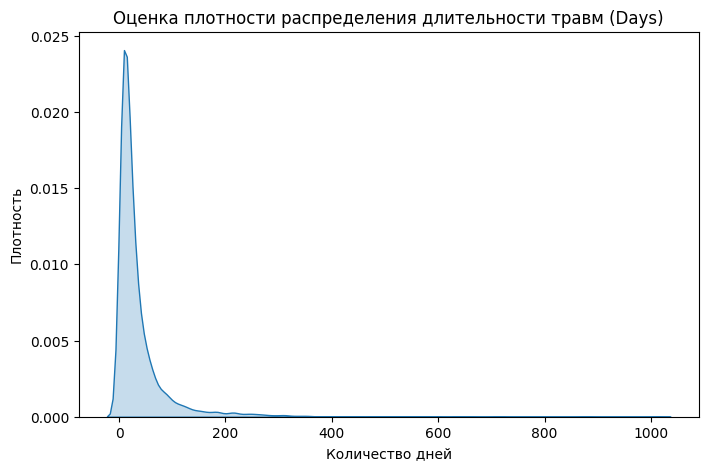

In [48]:
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=data,
    x="Days",
    fill=True
)

plt.title("Оценка плотности распределения длительности травм (Days)")
plt.xlabel("Количество дней")
plt.ylabel("Плотность")
plt.show()

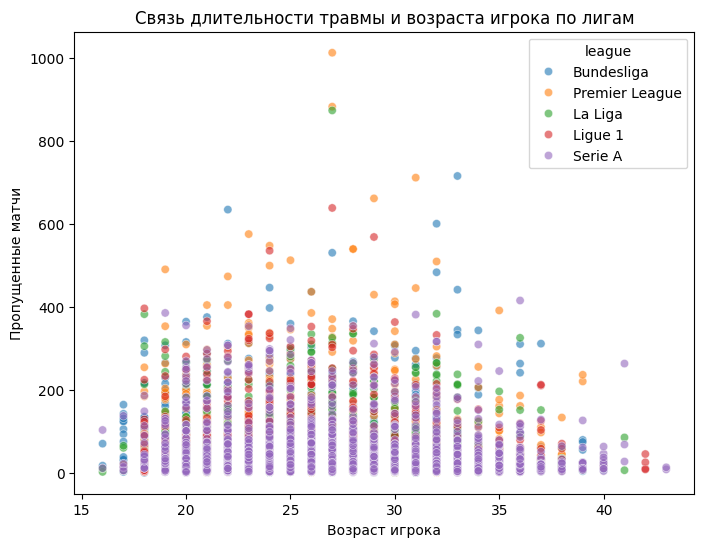

In [50]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=data,
    x="player_age",
    y="Days",
    hue="league",
    alpha=0.6
)

plt.title("Связь длительности травмы и возраста игрока по лигам")
plt.xlabel("Возраст игрока")
plt.ylabel("Пропущенные матчи")
plt.show()

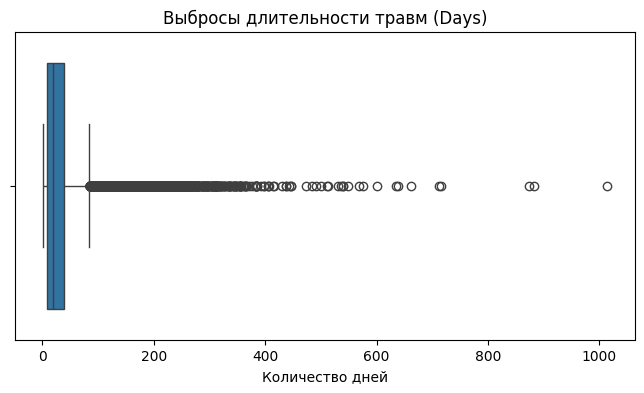

In [51]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data["Days"])
plt.title("Выбросы длительности травм (Days)")
plt.xlabel("Количество дней")
plt.show()

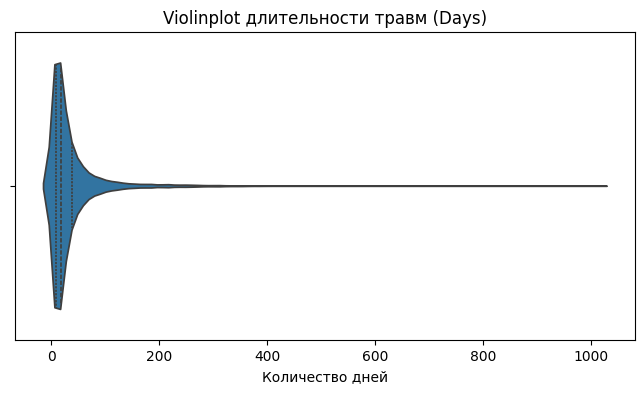

In [52]:
plt.figure(figsize=(8, 4))
sns.violinplot(x=data["Days"], inner="quartile")
plt.title("Violinplot длительности травм (Days)")
plt.xlabel("Количество дней")
plt.show()

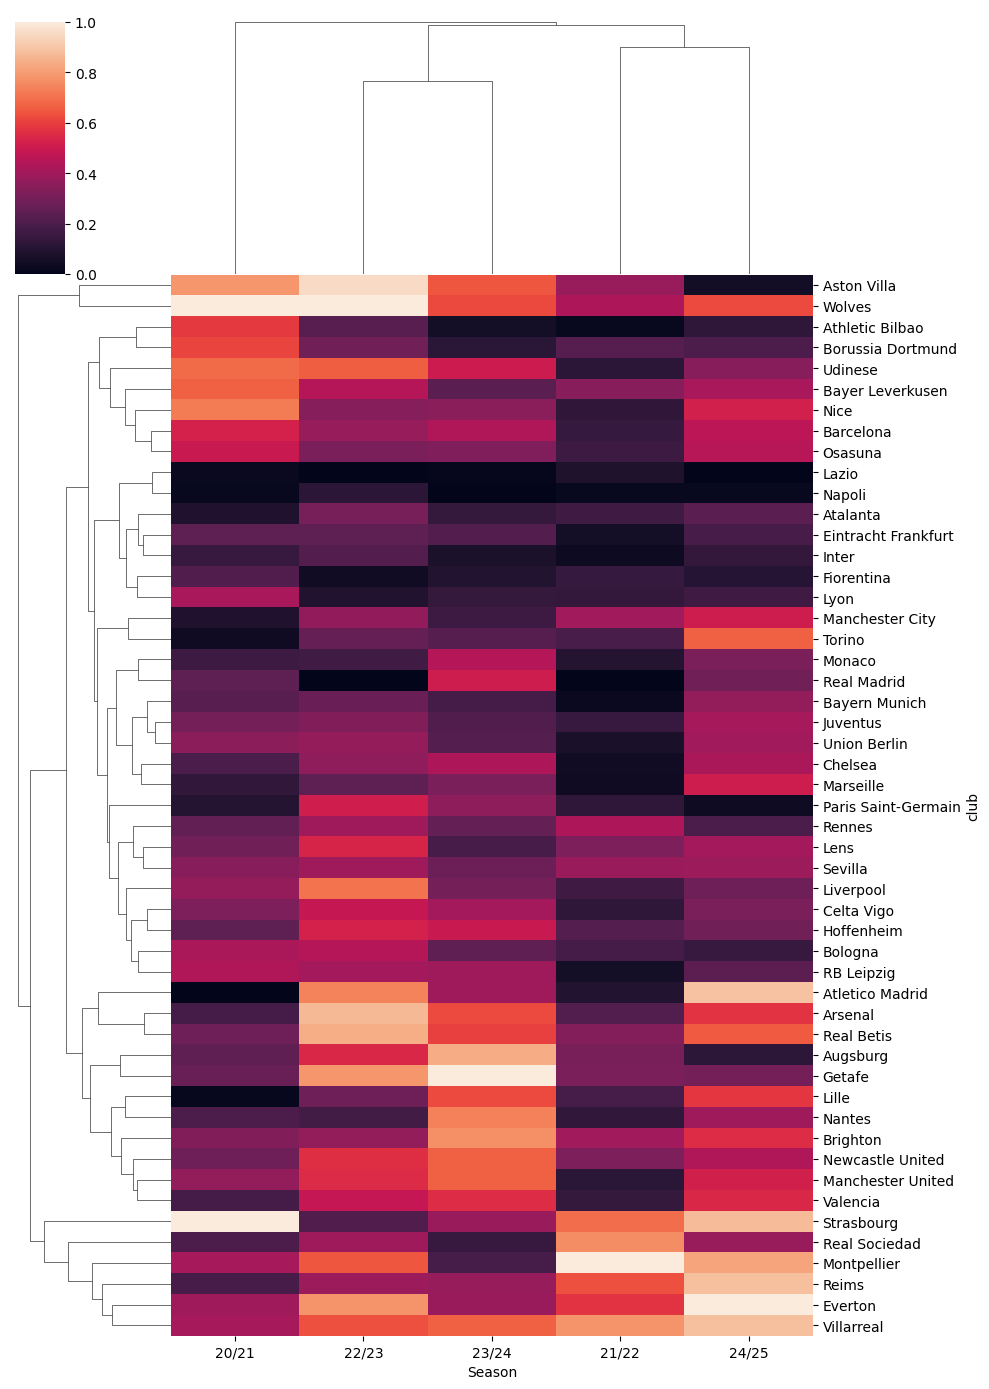

In [56]:
club_season = (
    data
    .pivot_table(
        index="club",
        columns="Season",
        values="Days",
        aggfunc="mean"
    )
    .dropna()
)

sns.clustermap(
    club_season,
    standard_scale=1,
    figsize=(10, 14)
)

## 6. Интерпритация и выводы

# 6. Интерпретация и выводы (на основе статистик и визуализаций из ноутбука)

## Какие признаки наиболее информативны?
**Числовые признаки (ключевые для анализа тяжести/влияния травмы):**
- **Days** — основной индикатор тяжести/длительности отсутствия.
- **Games missed** — прямой индикатор влияния травмы на участие в матчах.
- **player_age** — контекстный фактор риска/восстановления.

**Категориальные признаки (объясняют “где/у кого/какая травма”):**
- **Injury** (276 категорий) — позволяет выделять наиболее частые типы травм и сравнивать их по длительности/пропущенным матчам.
- **club** (145 категорий) и **league** (5 категорий) — дают контекст (клуб/лига) и позволяют искать устойчивые паттерны.
- **player_position** (14 категорий) — объясняет нагрузку и роль игрока.
- **Season** (5 категорий) — позволяет сравнивать сезоны и отслеживать динамику.

---

## Есть ли признаки с высоким уровнем пропусков или аномалий?
### Пропуски
- По результатам визуализации пропусков (heatmap `data.isna()`) **пропусков нет**: все ключевые поля заполнены.

### Аномалии (выбросы)
По boxplot/violinplot и статистическому правилу IQR:
- **Days**: выбросов ≈ **1497 записей**.
- **Games missed**: выбросов ≈ **1367 записей**.
- **player_age**: выбросов ≈ **11 записей** (возраст 41–43).  
  Эти значения выглядят **реалистично** и не обязательно требуют удаления.

**Вывод:** явных пропусков нет, но для **Days** и **Games missed** наблюдаются значимые выбросы, которые отражают редкие тяжёлые случаи и важны для анализа.

---

## Как распределены категории в крупном категориальном признаке?
Рассмотрим **club** (145 категорий, ≥20 категорий — требование выполнено):
- Распределение **неравномерное (long-tail)**: небольшое число клубов встречается часто, а большинство — заметно реже.
- Топ-5 по частоте (countplot Top-N подтверждает):
  - **Bayern Munich**: 349 (2.2%)
  - **Borussia Dortmund**: 349 (2.2%)
  - **Juventus**: 327 (2.1%)
  - **Hoffenheim**: 281 (1.8%)
  - **Real Madrid**: 278 (1.8%)
- Для “крупного” категориального признака корректно визуализировать **Top-20** клубов (иначе график перегружен).

---

## Какие кластеры выделяются на clustermap? Что они могут означать?
Был построен `clustermap` по матрице **club × Season**, где значения — средние **Days** (агрегация `mean`).
Также следует уточнить, что был указан `standard_scale=1`, а следовательно значения в каждом сезоне нормированы отдельно, и сравнение идёт между клубами внутри одного сезона (а не “абсолютно между сезонами”).

На clustermap выделяются следующие типы кластеров (их видно по группам строк с похожими цветными паттернами):
1) **Клубы со стабильно более длительными травмами** (тёмнее среднего в нескольких сезонах)  
   - возможные устойчивые особенности: профиль нагрузок, стиль игры, “тип” травм, глубина состава, особенности медицинского сопровождения.
2) **Клубы со стабильно менее длительными травмами** (светлее среднего в большинстве сезонов)  
   - травмы чаще “короткие”, либо более быстрое возвращение игроков.
3) **Клубы со “скачком” в одном сезоне** (в одном столбце заметно темнее, а в остальных — ближе к среднему)  
   - сезонный фактор: плотность календаря, серия тяжёлых травм, всплеск определённых травм, изменения тренерского/медицинского штаба.

Также кластеризация сезонов показывает, какие сезоны похожи по “профилю” средних длительностей травм среди клубов.

---

## Какие гипотезы можно сформулировать на основе визуализаций?
Ниже — гипотезы, которые опираются на статистики и графики и могут быть проверены дополнительным анализом:

1) **Связь возраста и длительности травмы слабая.**  
   - Основание: на графике scatterplot основная масса точек сосредоточена в возрасте 18–33, и именно там встречаются самые большие значения по оси Y (очень длительные травмы). Данный промежуток слишком большой и не имеет каких-то выделенных отклонений. У игроков старше 35 визуально реже встречаются экстремально долгие травмы — это может быть либо эффектом выборки (их меньше), либо особенностью нагрузки/ротации.
2) **В Premier League чаще встречаются экстремально длительные травмы.**  
   - Основание: на графике scatterplot “самые высокие” точки (очень большие значения Y) принадлежат не всем лигам равномерно — визуально Premier League даёт больше экстремумов.
3) **Определённые позиции имеют более высокий объём травм.**  
   - Основание: countplot по `player_position` — лидер **Centre-Back** (20.1%), далее Forward (14.4%) и Central Midfield (12.2%).
4) **Lazio и Napoli очень сильно страдают от травм.**  
   - Основание: clustermap показывает, что данные клубы самые темные во всех сезонах, что можно интерпретировать самым большим количеством пропущенных дней среди всех клубов.
5) **Есть различия по лигам в объёме зафиксированных случаев.**  
   - Основание: countplot по `league`: Serie A (26.3%) и Bundesliga (26.2%) имеют больше записей, чем La Liga (13.9%).

---

## Итоговые выводы (кратко)
- Наиболее информативные признаки для “тяжести” травмы: **Days** и **Games missed**; для контекста: **Injury, club, league, player_position, Season**.
- Пропусков практически нет, но для **Days** и **Games missed** выявлены выраженные выбросы, что подтверждается boxplot/histplot и разницей среднего и медианы.
- `club` имеет распределение “длинного хвоста”: много редких категорий и небольшой топ часто встречающихся клубов (поэтому в визуализациях лучше использовать Top-N).
- Clustermap выделяет группы клубов со схожим сезонным профилем средней длительности травм, что позволяет формулировать проверяемые гипотезы о различиях между клубами/сезонами.